In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pymcdm.methods import TOPSIS, VIKOR, SPOTIS
from pymcdm.helpers import rrankdata, rankdata
from pymcdm.visuals import ranking_flows
from pymcdm.normalizations import vector_normalization, linear_normalization, minmax_normalization

## Kryteria: 


- cena(zł): koszt, 
- czynsz(zł): koszt, 
- metraż(m2): zysk,
- stan(1-4): zysk. 1 = remont generalny, 2 = remont, 3 = do odświeżenia, 4 = gotowe do wprowadzenia,
- piętro: zysk,
- przestrzenie dodatkowe (garaż, piwnica, strych, ogródek, komórka lokatorska): zysk. Każda z dodatkowych przestrzeni oznacza +1 do wartości. 
- odległość od centrum(km): koszt,
- odległość od przystanku komunikacji zbiorowej(m): koszt.


In [134]:
D = np.array([
    [699000, 670, 69, 3, 0, 2, 4.6, 550],  
    [750000, 425, 73, 4, 4, 2, 4.8, 800],  
    [495000, 600, 55, 2, 0, 2, 4.3, 500],  
    [399000, 300, 54, 1, 2, 1, 3.9, 220],  
    [435000, 420, 56, 1, 2, 2, 3.8, 120],  
    [500000, 225, 47, 4, 1, 1, 4.0, 400],  
    [629000, 800, 63, 2, 5, 3, 4.3, 650],  
    [580000, 280, 48, 4, 2, 3, 4.5, 500]]) 

bounds = np.array([[399000, 750000], [225, 800], [47, 73], [1, 4], [0, 5], [0, 4], [3.0, 4.8], [120, 800]], dtype=float)
weights = np.array([0.2, 0.2, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1])
types = np.array([-1, -1, 1, 1, 1, 1, -1, -1])

In [135]:
def min_max(x):
    criterias = 8
    for j in range(criterias - 1):
        x_min = x.min(axis=0)
        x_max = x.max(axis=0)
        X = (x - x_min) / (x_max - x_min)
    return X 

print(min_max(D))

[[0.85470085 0.77391304 0.84615385 0.66666667 0.         0.5
  0.8        0.63235294]
 [1.         0.34782609 1.         1.         0.8        0.5
  1.         1.        ]
 [0.27350427 0.65217391 0.30769231 0.33333333 0.         0.5
  0.5        0.55882353]
 [0.         0.13043478 0.26923077 0.         0.4        0.
  0.1        0.14705882]
 [0.1025641  0.33913043 0.34615385 0.         0.4        0.5
  0.         0.        ]
 [0.28774929 0.         0.         1.         0.2        0.
  0.2        0.41176471]
 [0.65527066 1.         0.61538462 0.33333333 1.         1.
  0.5        0.77941176]
 [0.51566952 0.09565217 0.03846154 1.         0.4        1.
  0.7        0.55882353]]


In [136]:
def my_topsis(D, weights, types):
    D_norm = min_max(D)
    D_typed = D_norm * types
    D_weighted = D_typed * weights
    pis = np.max(D_weighted, axis=0)
    nis = np.min(D_weighted, axis=0)
    dist_pis = np.sqrt(np.sum((D_weighted - pis) ** 2, axis=1))
    dist_nis = np.sqrt(np.sum((D_weighted - nis) ** 2, axis=1))
    scores = dist_nis / (dist_pis + dist_nis)
    return scores
my_implementation = my_topsis(D, weights, types)
print(my_implementation)

[0.32977761 0.45153843 0.46209491 0.63153593 0.63212277 0.61410537
 0.40291826 0.59102131]


Alternatywa 1: Miejsce w rankingu 8.0
Alternatywa 2: Miejsce w rankingu 6.0
Alternatywa 3: Miejsce w rankingu 5.0
Alternatywa 4: Miejsce w rankingu 2.0
Alternatywa 5: Miejsce w rankingu 1.0
Alternatywa 6: Miejsce w rankingu 3.0
Alternatywa 7: Miejsce w rankingu 7.0
Alternatywa 8: Miejsce w rankingu 4.0


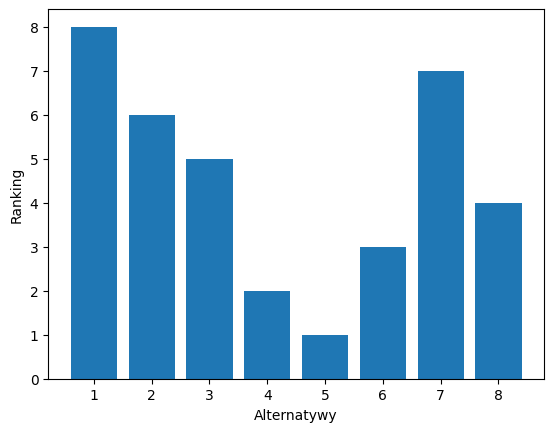

In [ ]:
ranking = rrankdata(my_implementation)
for i, r in enumerate(ranking):
    print(f"Alternatywa {i + 1}: Miejsce w rankingu {r}")
plt.bar(range(1, len(ranking) + 1), len(ranking)-ranking+1)
plt.xlabel('Alternatywy')
plt.ylabel('Ranking')
plt.show()

In [138]:
body_topsis = TOPSIS()
pref = body_topsis(D, weights, types)
print("TOPSIS:", pref)
ranking_topsis = rrankdata(pref)
for i, r in enumerate(ranking_topsis):
    print(f"Alternatywa {i + 1}: Ranking {r}")


TOPSIS: [0.32977761 0.45153843 0.46209491 0.63153593 0.63212277 0.61410537
 0.40291826 0.59102131]
Alternatywa 1: Ranking 8.0
Alternatywa 2: Ranking 6.0
Alternatywa 3: Ranking 5.0
Alternatywa 4: Ranking 2.0
Alternatywa 5: Ranking 1.0
Alternatywa 6: Ranking 3.0
Alternatywa 7: Ranking 7.0
Alternatywa 8: Ranking 4.0


<Axes: ylabel='Position in ranking'>

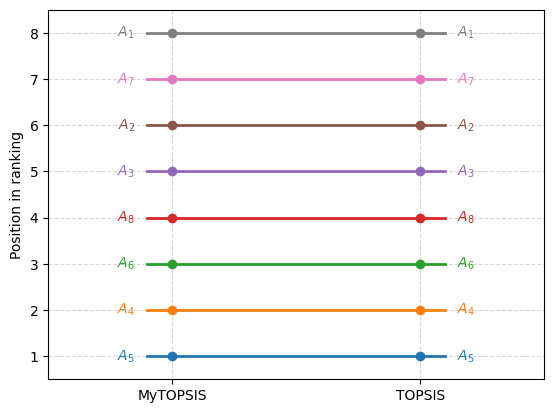

In [139]:
ranking_flows([ranking, ranking_topsis], ['MyTOPSIS', 'TOPSIS'])



In [140]:
body_vikor= VIKOR()
print("VIKOR:", body_vikor(D, weights, types))
ranking_vikor = rankdata(body_vikor(D, weights, types))
print("Ranking VIKOR:", ranking_vikor)

body_spotis = SPOTIS(bounds)
print("SPOTIS:", body_spotis(D, weights, types))
ranking_spotis = rankdata(body_spotis(D, weights, types))
print("Ranking SPOTIS:", ranking_spotis)

VIKOR: [0.85470085 0.78925851 0.50287329 0.03314044 0.         0.0575794
 0.82965676 0.08241846]
Ranking VIKOR: [8. 6. 5. 2. 1. 3. 7. 4.]
SPOTIS: [0.67656491 0.53956522 0.59913765 0.39886976 0.40816797 0.40928188
 0.61134573 0.44263387]
Ranking SPOTIS: [8. 5. 6. 1. 2. 3. 7. 4.]


<Axes: ylabel='Position in ranking'>

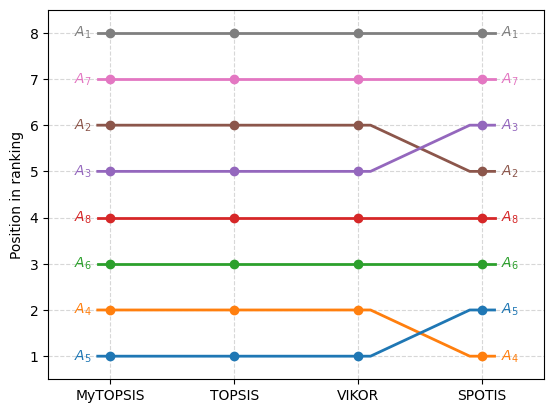

In [141]:
ranking_flows([ranking, ranking_topsis ,ranking_vikor, ranking_spotis], ['MyTOPSIS', 'TOPSIS' ,'VIKOR', 'SPOTIS'])

My TOPSIS with vector normalization: [0.14529976 0.0010679  0.72649392 0.99974175 0.89743467 0.71225112
 0.34472853 0.4843316 ]
My TOPSIS with linear normalization: [0.14529976 0.0010679  0.72649392 0.99974175 0.89743467 0.71225112
 0.34472853 0.4843316 ]
My TOPSIS with min-max normalization: [0.14529976 0.0010679  0.72649392 0.99974175 0.89743467 0.71225112
 0.34472853 0.4843316 ]


<Axes: ylabel='Position in ranking'>

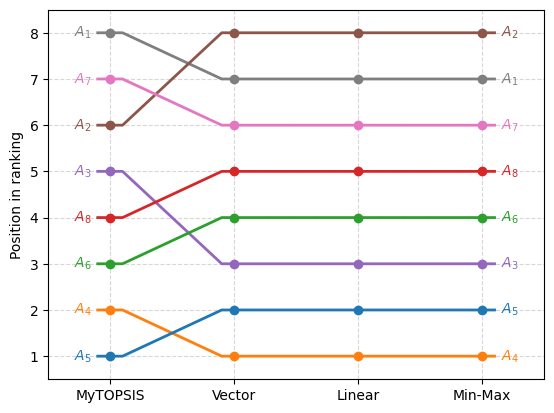

In [142]:
def my_topsis_vector(D, weights, types):
    D_norm = vector_normalization(D)
    D_typed = D_norm * types
    D_weighted = D_typed * weights
    pis = np.max(D_weighted, axis=0)
    nis = np.min(D_weighted, axis=0)
    dist_pis = np.sqrt(np.sum((D_weighted - pis) ** 2, axis=1))
    dist_nis = np.sqrt(np.sum((D_weighted - nis) ** 2, axis=1))
    scores_vector = dist_nis / (dist_pis + dist_nis)
    return scores_vector
my_implementation_vector = my_topsis_vector(D, weights, types)
print("My TOPSIS with vector normalization:", my_implementation_vector)
ranking_vector = rrankdata(my_implementation_vector)

def my_topsis_linear(D, weights, types):
    D_norm = linear_normalization(D)
    D_typed = D_norm * types
    D_weighted = D_typed* weights
    pis = np.max(D_weighted, axis=0)
    nis = np.min(D_weighted, axis=0)
    dist_pis = np.sqrt(np.sum((D_weighted - pis) ** 2, axis=1))
    dist_nis = np.sqrt(np.sum((D_weighted - nis) ** 2, axis=1))
    scores_linear = dist_nis / (dist_pis + dist_nis)
    return scores_linear
my_implementation_linear = my_topsis_linear(D, weights, types)
print("My TOPSIS with linear normalization:", my_implementation_linear)
ranking_linear = rrankdata(my_implementation_linear)

def my_topsis_minmax(D, weights, types):
    D_norm = minmax_normalization(D)
    D_typed = D_norm * types
    D_weighted = D_typed * weights
    pis = np.max(D_weighted, axis=0)
    nis = np.min(D_weighted, axis=0)
    dist_pis = np.sqrt(np.sum((D_weighted - pis) ** 2, axis=1))
    dist_nis = np.sqrt(np.sum((D_weighted - nis) ** 2, axis=1))
    scores_minmax = dist_nis / (dist_pis + dist_nis)
    return scores_minmax
my_implementation_minmax = my_topsis_minmax(D, weights, types)
print("My TOPSIS with min-max normalization:", my_implementation_minmax)
ranking_minmax = rrankdata(my_implementation_minmax)

ranking_flows([ranking, ranking_vector, ranking_linear, ranking_minmax], ['MyTOPSIS', 'Vector', 'Linear', 'Min-Max'])

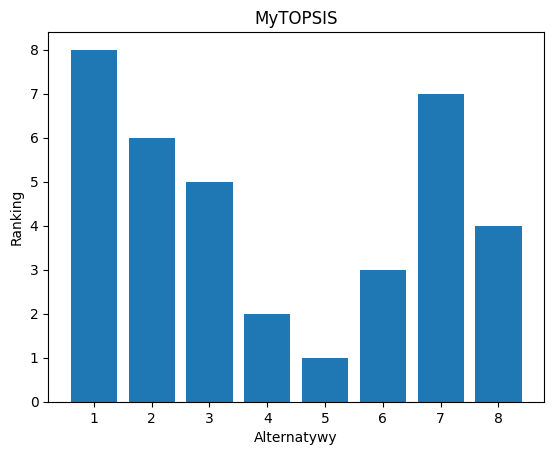

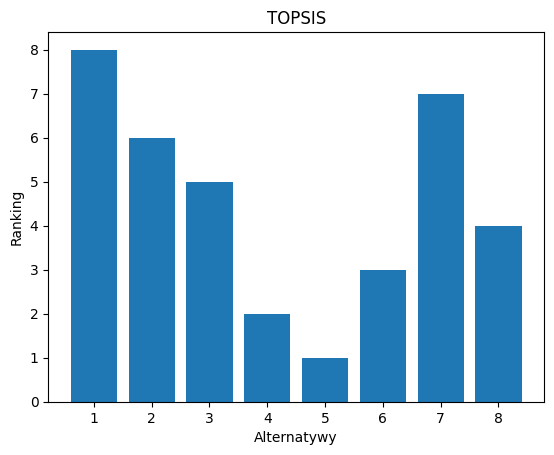

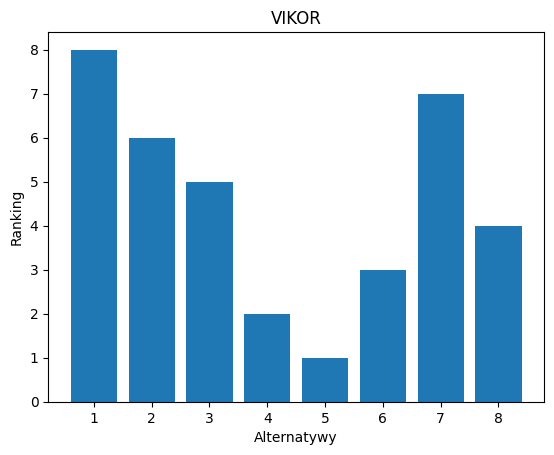

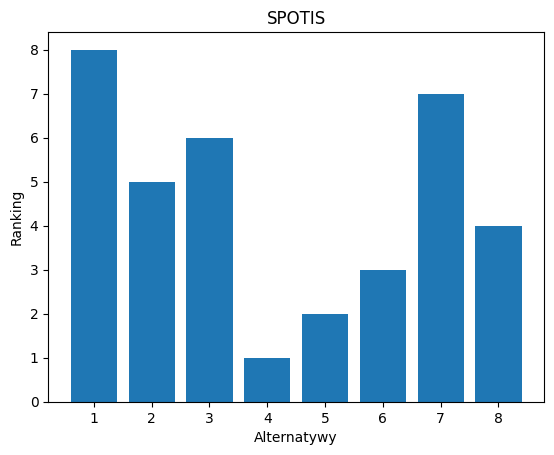

In [ ]:
for ranking, label in zip([ranking, ranking_topsis, ranking_vikor, ranking_spotis], ['MyTOPSIS', 'TOPSIS' ,'VIKOR', 'SPOTIS']):
    plt.bar(range(1, len(ranking) + 1), ranking)
    plt.xlabel('Alternatywy')
    plt.ylabel('Ranking')
    plt.title(label)
    plt.show()